In [1]:
# ==== USGS Streamflow Analysis and Comparison (UPDATED FOR ADDITIONAL DATA) ====
print("=== STREAMFLOW DATA ANALYSIS ===")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import re
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries loaded successfully")

# ==== Load Enhanced Data from Artifacts ====
print("\n=== LOADING ENHANCED DATA FROM ARTIFACTS ===")

from artifacts_io import load_artifacts

# Load artifacts that include both main and additional data
tables, meta, run_dir = load_artifacts(out_dir="artifacts")
run_id = os.path.basename(run_dir)
print(f"Loaded artifacts from: {run_dir}")

# Get the combined dataset
if "df_combined" in tables:
    restored_df_all = tables["df_combined"].copy()
    print(f"Using df_combined: {len(restored_df_all):,} total sites")
elif "df" in tables:
    restored_df_all = tables["df"].copy()
    print(f"Using df: {len(restored_df_all):,} total sites")
else:
    # Use the largest table
    everything_key = max(tables, key=lambda k: tables[k].shape[0])
    restored_df_all = tables[everything_key].copy()
    print(f"Using {everything_key}: {len(restored_df_all):,} total sites")

# Check for data source information
if 'data_source' in restored_df_all.columns:
    print("Total data source breakdown:")
    print(restored_df_all['data_source'].value_counts())

print("Enhanced dataset loaded successfully")

# ==== Filter to Santa Barbara County Only ====
print("\n=== FILTERING TO SANTA BARBARA COUNTY ===")

# Load Santa Barbara County boundary first
sb_county_shapefile = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\sb_county_shapefile\sb_county_shp.shp"

try:
    sb_county = gpd.read_file(sb_county_shapefile)
    if sb_county.crs is None or sb_county.crs.to_string().upper() not in ("EPSG:4326", "WGS84"):
        sb_county = sb_county.to_crs("EPSG:4326")
    
    sb_county_geom = sb_county.union_all() if hasattr(sb_county, "union_all") else sb_county.unary_union
    SB_COUNTY_GDF = gpd.GeoSeries([sb_county_geom], crs="EPSG:4326")
    print("Loaded Santa Barbara County boundary for filtering")
    
    # Create GeoDataFrame for filtering
    coord_cols = ['lon_combined', 'lat_combined'] if 'lon_combined' in restored_df_all.columns else ['longitude', 'latitude']
    restored_gdf_all = gpd.GeoDataFrame(
        restored_df_all,
        geometry=gpd.points_from_xy(restored_df_all[coord_cols[0]], restored_df_all[coord_cols[1]]),
        crs="EPSG:4326"
    )
    
    # Filter to Santa Barbara County only
    within_sb = restored_gdf_all.within(sb_county_geom)
    restored_df = restored_df_all.loc[within_sb].copy()
    
    print(f"Filtered from {len(restored_df_all):,} total sites to {len(restored_df):,} Santa Barbara County sites")
    
    if 'data_source' in restored_df.columns:
        print("Santa Barbara data source breakdown:")
        print(restored_df['data_source'].value_counts())
    
except FileNotFoundError:
    print("ERROR: County boundary file not found - cannot filter to Santa Barbara County")
    raise
except Exception as e:
    print(f"ERROR filtering to Santa Barbara County: {e}")
    raise

# ==== Load Streamflow Data from CSV Files ====
print("\n=== LOADING STREAMFLOW DATA FROM CSV FILES ===")

# Define file paths - Updated to use your measurement data
nwis_measurements_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_usgs_1800_1979.csv")
nwis_sites_csv = Path(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_sites_for_mapping.csv")

try:
    # Load NWIS measurement data (individual measurements)
    print("Loading NWIS streamflow measurements...")
    nwis_measurements = pd.read_csv(nwis_measurements_csv)
    print(f"Loaded NWIS measurements: {len(nwis_measurements):,} individual measurements")
    
    # Parse dates and extract year
    nwis_measurements['measurement_dt'] = pd.to_datetime(nwis_measurements['measurement_dt'], errors='coerce')
    nwis_measurements['year'] = nwis_measurements['measurement_dt'].dt.year
    nwis_measurements['decade'] = (nwis_measurements['year'] // 10) * 10
    
    # Load NWIS site summary (unique sites)
    print("Loading NWIS site summary...")
    nwis_sites = pd.read_csv(nwis_sites_csv)
    print(f"Loaded NWIS sites: {len(nwis_sites):,} unique sites")
    
    # Filter to stream discharge sites only from the enhanced dataset
    print("Filtering enhanced dataset to stream discharge sites...")
    historical_streams = restored_df[restored_df['water_type_clean'] == 'Stream discharge'].copy()
    print(f"Historical stream discharge sites: {len(historical_streams):,}")
    
    # Show breakdown by data source if available
    if 'data_source' in historical_streams.columns:
        print("Stream discharge sites by data source:")
        print(historical_streams['data_source'].value_counts())
    
    # Add decade column for historical data
    if 'year_start' in historical_streams.columns:
        historical_streams['decade'] = (historical_streams['year_start'] // 10) * 10
    elif 'start_year' in historical_streams.columns:
        historical_streams['decade'] = (historical_streams['start_year'] // 10) * 10
    else:
        print("Warning: No start year column found in historical data")
        historical_streams['decade'] = 1940
    
    print(f"Data loaded successfully")
    
    # We need coordinates for NWIS sites - get them from NWIS web services
    print("\nGetting coordinates for NWIS sites...")
    from dataretrieval import nwis as nwis_service
    
    # Get unique site numbers
    unique_sites = nwis_sites['site_no'].unique()
    print(f"Getting coordinates for {len(unique_sites)} NWIS sites...")
    
    # Get site information including coordinates
    site_info = nwis_service.get_info(sites=unique_sites.tolist())
    site_coords = site_info[0][['site_no', 'dec_lat_va', 'dec_long_va']].copy()
    site_coords = site_coords.rename(columns={'dec_lat_va': 'latitude', 'dec_long_va': 'longitude'})
    
    # Convert site_no to string in ALL DataFrames BEFORE merging
    print("Converting site_no columns to consistent data types...")
    nwis_sites['site_no'] = nwis_sites['site_no'].astype(str)
    site_coords['site_no'] = site_coords['site_no'].astype(str)
    nwis_measurements['site_no'] = nwis_measurements['site_no'].astype(str)
    
    # NOW do the merges
    print("Merging coordinate data...")
    nwis_sites_with_coords = nwis_sites.merge(site_coords, on='site_no', how='left')
    
    # Create GeoDataFrames for sites - use processed coordinate columns
    coord_cols = ['longitude', 'latitude']  # from NWIS
    historical_coord_cols = ['lon_combined', 'lat_combined']  # from your processing
    if 'longitude' not in historical_streams.columns and 'lon_combined' in historical_streams.columns:
        historical_coord_cols = ['lon_combined', 'lat_combined']
    elif 'longitude' in historical_streams.columns:
        historical_coord_cols = ['longitude', 'latitude']
    
    nwis_sites_gdf = gpd.GeoDataFrame(
        nwis_sites_with_coords,
        geometry=gpd.points_from_xy(nwis_sites_with_coords['longitude'], nwis_sites_with_coords['latitude']),
        crs="EPSG:4326"
    )
    nwis_sites_gdf['data_type'] = 'NWIS USGS'
    
    # Create GeoDataFrame for historical sites using correct coordinate columns
    historical_sites_gdf = gpd.GeoDataFrame(
        historical_streams,
        geometry=gpd.points_from_xy(historical_streams[historical_coord_cols[0]], historical_streams[historical_coord_cols[1]]),
        crs="EPSG:4326"
    )
    historical_sites_gdf['data_type'] = 'Restored USGS'

except Exception as e:
    print(f"ERROR: {e}")
    print("Check file paths and ensure dataretrieval package is installed")

print(f"Created GeoDataFrames successfully")
print(f"  - NWIS sites: {len(nwis_sites_gdf):,}")
print(f"  - Historical sites (enhanced): {len(historical_sites_gdf):,}")

=== STREAMFLOW DATA ANALYSIS ===
Libraries loaded successfully

=== LOADING ENHANCED DATA FROM ARTIFACTS ===
Loaded artifacts from: artifacts\run_20250901_113434
Using df_combined: 109,626 total sites
Total data source breakdown:
data_source
main          107314
additional      2312
Name: count, dtype: int64
Enhanced dataset loaded successfully

=== FILTERING TO SANTA BARBARA COUNTY ===
Loaded Santa Barbara County boundary for filtering
Filtered from 109,626 total sites to 6,786 Santa Barbara County sites
Santa Barbara data source breakdown:
data_source
main          4992
additional    1794
Name: count, dtype: int64

=== LOADING STREAMFLOW DATA FROM CSV FILES ===
Loading NWIS streamflow measurements...
Loaded NWIS measurements: 1,948 individual measurements
Loading NWIS site summary...
Loaded NWIS sites: 21 unique sites
Filtering enhanced dataset to stream discharge sites...
Historical stream discharge sites: 2,516
Stream discharge sites by data source:
data_source
main          2400
a

In [6]:
import os
from matplotlib.lines import Line2D

=== FILTERING FOR SANTA YNEZ RIVER SITES ===
Available columns in historical_streams:
['id', 'page_number', 'inferred_latitude', 'inferred_longitude', 'actual_latitude', 'actual_longitude', 'location', 'townships_ranges_sections', 'watersource_name', 'actual_county', 'inferred_county', 'dates_of_recording_raw', 'temporal_resolution', 'units_of_measurement', 'water_type', 'keyterms', 'data_source', 'id_page_number', 'latitude', 'longitude', 'water_type_clean', 'water_type_review', 'year_start', 'year_end', 'years_list', 'date_parse_status', 'date_parse_notes', 'needs_date_review', 'decade']

Total historical stream sites: 2516

Potential location/name columns: ['location', 'watersource_name', 'data_source']

Found 87 matches in column 'location'
Examples: ['Santa Ynez River Valley, California', 'Near Lompoc, California, on the left bank of Santa Ynez River, 0.5 mile upstream from State Highway 150, 1.9 miles east of Lompoc.', 'Near Highway 150 crossing about 0.5 mile above junction with

C:\Users\aeliz\miniforge3\envs\hydro\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


✓ Successfully loaded 1653 features using fiona

✓ RIVERS DATA LOADED SUCCESSFULLY!
Rivers data contains 1653 features
Available columns: ['NHDFlowline_Clip_COMID', 'NHDFlowline_Clip_FDATE', 'NHDFlowline_Clip_RESOLUTION', 'NHDFlowline_Clip_GNIS_ID', 'NHDFlowline_Clip_GNIS_NAME', 'NHDFlowline_Clip_LENGTHKM', 'NHDFlowline_Clip_REACHCODE', 'NHDFlowline_Clip_FLOWDIR', 'NHDFlowline_Clip_WBAREACOMI', 'NHDFlowline_Clip_FTYPE', 'NHDFlowline_Clip_FCODE', 'NHDFlowline_Clip_SHAPE_LENG', 'NHDFlowline_Clip_ENABLED', 'NHDFlowline_Clip_GNIS_NBR', 'PlusFlowlineVAA_OID', 'PlusFlowlineVAA_ComID', 'PlusFlowlineVAA_Fdate', 'PlusFlowlineVAA_StreamLeve', 'PlusFlowlineVAA_StreamOrde', 'PlusFlowlineVAA_StreamCalc', 'PlusFlowlineVAA_FromNode', 'PlusFlowlineVAA_ToNode', 'PlusFlowlineVAA_Hydroseq', 'PlusFlowlineVAA_LevelPathI', 'PlusFlowlineVAA_Pathlength', 'PlusFlowlineVAA_TerminalPa', 'PlusFlowlineVAA_ArbolateSu', 'PlusFlowlineVAA_Divergence', 'PlusFlowlineVAA_StartFlag', 'PlusFlowlineVAA_TerminalFl', 'PlusFlo

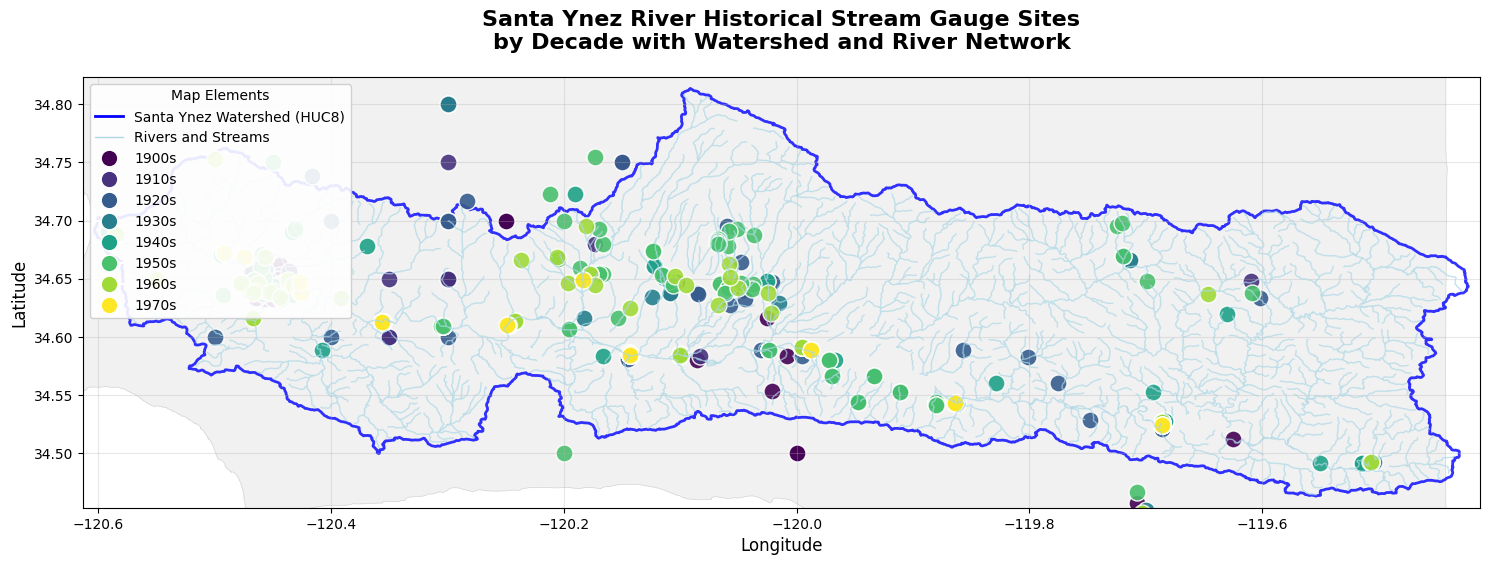


=== SUMMARY STATISTICS ===
Total Santa Ynez River sites found: 849

Sites by decade:
  1900s: 84 sites
  1910s: 47 sites
  1920s: 110 sites
  1930s: 41 sites
  1940s: 157 sites
  1950s: 157 sites
  1960s: 99 sites
  1970s: 27 sites

Sites by data source:
  main: 823 sites
  additional: 26 sites


In [7]:
# ==== FILTER HISTORICAL SITES FOR SANTA YNEZ RIVER ====
print("=== FILTERING FOR SANTA YNEZ RIVER SITES ===")

import re

# First, let's examine what columns we have in historical_streams
print("Available columns in historical_streams:")
print(list(historical_streams.columns))
print(f"\nTotal historical stream sites: {len(historical_streams)}")

# Look for columns that might contain location or water source information
location_columns = [col for col in historical_streams.columns if any(keyword in col.lower() for keyword in ['location', 'name', 'source', 'station', 'site'])]
print(f"\nPotential location/name columns: {location_columns}")

# Create a function to search for Santa Ynez River variations
def contains_santa_ynez(text):
    """
    Check if text contains Santa Ynez River or variations
    Case insensitive search for various spellings
    """
    try:
        # Handle various data types that might be in the columns
        if text is None:
            return False
        if hasattr(text, '__len__') and not isinstance(text, str):
            # Handle arrays, lists, etc. - convert to string
            text_str = str(text).lower()
        elif pd.isna(text):
            return False
        elif text == '':
            return False
        else:
            text_str = str(text).lower()
        
        # Define patterns for Santa Ynez River variations
        patterns = [
            r'santa\s+ynez\s+r',  # Santa Ynez R (river abbreviated)
            r'santa\s+ynez\s+river',  # Santa Ynez River
            r'santa\s+inez\s+r',  # Alternative spelling: Santa Inez
            r'santa\s+inez\s+river',
            r'sta\s+ynez',  # Abbreviated Santa
            r'st\s+ynez',   # Another abbreviation
            r'santa\s+yanez', # Alternative spelling
            r'sante\s+ynez', # Misspelling
        ]
        
        for pattern in patterns:
            if re.search(pattern, text_str):
                return True
        return False
    except Exception as e:
        # If any error occurs, return False and continue
        return False

# Search through all potential columns (excluding problematic ones)
santa_ynez_sites = pd.DataFrame()
search_results = {}

# Define columns to skip
skip_columns = ['keyterms']

for col in historical_streams.columns:
    if col in skip_columns:
        print(f"Skipping column '{col}' (known to cause issues)")
        continue
        
    if historical_streams[col].dtype == 'object':  # Only search text columns
        try:
            matches = historical_streams[historical_streams[col].apply(contains_santa_ynez)]
            if len(matches) > 0:
                search_results[col] = len(matches)
                print(f"\nFound {len(matches)} matches in column '{col}'")
                # Show some example values
                examples = matches[col].unique()[:5]
                print(f"Examples: {list(examples)}")
        except Exception as e:
            print(f"Error searching column '{col}': {e}")
            continue

# Combine all matches (remove duplicates by index)
all_matches_indices = set()
for col in historical_streams.columns:
    if col in skip_columns:
        continue
        
    if historical_streams[col].dtype == 'object':
        try:
            matches_idx = historical_streams[historical_streams[col].apply(contains_santa_ynez)].index
            all_matches_indices.update(matches_idx)
        except Exception as e:
            print(f"Error processing column '{col}': {e}")
            continue

# Get all Santa Ynez sites
santa_ynez_sites = historical_streams.loc[list(all_matches_indices)].copy()

print(f"\n=== SANTA YNEZ RIVER SITES FOUND ===")
print(f"Total Santa Ynez River sites: {len(santa_ynez_sites)}")

if len(santa_ynez_sites) > 0:
    # Show summary information
    print(f"\nColumns with matches: {list(search_results.keys())}")
    
    # Show year range if available
    year_cols = [col for col in santa_ynez_sites.columns if 'year' in col.lower()]
    print(f"Available year columns: {year_cols}")
    
    if year_cols:
        for year_col in year_cols:
            if santa_ynez_sites[year_col].notna().any():
                try:
                    # Check if the column contains arrays/lists or scalar values
                    sample_value = santa_ynez_sites[year_col].dropna().iloc[0] if len(santa_ynez_sites[year_col].dropna()) > 0 else None
                    
                    if sample_value is not None:
                        if hasattr(sample_value, '__len__') and not isinstance(sample_value, str):
                            # Column contains arrays/lists - flatten them
                            all_years = []
                            for val in santa_ynez_sites[year_col].dropna():
                                if hasattr(val, '__len__') and not isinstance(val, str):
                                    all_years.extend([y for y in val if pd.notna(y)])
                                else:
                                    if pd.notna(val):
                                        all_years.append(val)
                            
                            if all_years:
                                min_year = min(all_years)
                                max_year = max(all_years)
                                print(f"Year range in {year_col}: {min_year} - {max_year}")
                            else:
                                print(f"No valid years found in {year_col}")
                        else:
                            # Column contains scalar values
                            min_year = santa_ynez_sites[year_col].min()
                            max_year = santa_ynez_sites[year_col].max()
                            print(f"Year range in {year_col}: {min_year} - {max_year}")
                except Exception as e:
                    print(f"Error processing year column {year_col}: {e}")
                    # Try to show some sample values to understand the data structure
                    print(f"Sample values in {year_col}:")
                    sample_vals = santa_ynez_sites[year_col].dropna().head(3).tolist()
                    print(sample_vals)
    
    # Show decade distribution if available
    if 'decade' in santa_ynez_sites.columns:
        print(f"\nDecade distribution:")
        decade_counts = santa_ynez_sites['decade'].value_counts().sort_index()
        print(decade_counts)
    
    # Display detailed information about each site
    print(f"\n=== DETAILED SANTA YNEZ RIVER SITES ===")
    
    # Select relevant columns for display
    display_cols = []
    for col in ['site_id', 'station_name', 'location', 'water_source_name', 'year_start', 'year_end', 'decade', 'data_source']:
        if col in santa_ynez_sites.columns:
            display_cols.append(col)
    
    # Add coordinate columns
    coord_cols = ['lon_combined', 'lat_combined'] if 'lon_combined' in santa_ynez_sites.columns else ['longitude', 'latitude']
    for col in coord_cols:
        if col in santa_ynez_sites.columns:
            display_cols.append(col)
    
    print(f"Displaying columns: {display_cols}")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print(santa_ynez_sites[display_cols])
    
    # Create a GeoDataFrame for mapping
    print(f"\n=== CREATING GEODATAFRAME FOR MAPPING ===")
    
    # Use the same coordinate columns as determined earlier
    santa_ynez_gdf = gpd.GeoDataFrame(
        santa_ynez_sites,
        geometry=gpd.points_from_xy(santa_ynez_sites[historical_coord_cols[0]], santa_ynez_sites[historical_coord_cols[1]]),
        crs="EPSG:4326"
    )
    
    print(f"Created Santa Ynez GeoDataFrame with {len(santa_ynez_gdf)} sites")
    
    # ==== ENHANCED RIVERS LOADING WITH ARCPY AND FIONA FALLBACK ====
    print(f"\n=== LOADING RIVERS DATA WITH ENHANCED METHODS ===")
    
    def load_rivers_with_arcpy(gdb_path, shp_path):
        """
        Attempt to load rivers data using arcpy
        """
        try:
            import arcpy
            print("✓ ArcPy available - attempting to load with arcpy...")
            
            # Set up arcpy environment
            arcpy.env.overwriteOutput = True
            
            # First try the geodatabase
            if gdb_path and os.path.exists(gdb_path):
                print(f"Checking geodatabase: {gdb_path}")
                
                # List feature classes in the geodatabase
                arcpy.env.workspace = gdb_path
                feature_classes = arcpy.ListFeatureClasses()
                print(f"Feature classes found: {feature_classes}")
                
                # Look for rivers/streams feature classes
                river_keywords = ['stream', 'river', 'water', 'hydro', 'flow', 'streamsandrivers']
                potential_fcs = []
                
                for fc in feature_classes:
                    fc_lower = fc.lower()
                    if any(keyword in fc_lower for keyword in river_keywords):
                        potential_fcs.append(fc)
                
                print(f"Potential river feature classes: {potential_fcs}")
                
                # Try to load the most promising feature class
                target_fc = None
                if potential_fcs:
                    target_fc = potential_fcs[0]
                elif feature_classes:
                    target_fc = feature_classes[0]  # Fallback to first FC
                
                if target_fc:
                    print(f"Loading feature class: {target_fc}")
                    
                    # Describe the feature class
                    desc = arcpy.Describe(target_fc)
                    print(f"Feature class type: {desc.shapeType}")
                    print(f"Spatial reference: {desc.spatialReference.name}")
                    print(f"Feature count: {arcpy.GetCount_management(target_fc).getOutput(0)}")
                    
                    # Convert to GeoDataFrame using arcpy and geopandas
                    # Create a temporary shapefile if needed
                    import tempfile
                    temp_dir = tempfile.mkdtemp()
                    temp_shp = os.path.join(temp_dir, "temp_rivers.shp")
                    
                    # Copy features to temporary shapefile
                    arcpy.CopyFeatures_management(target_fc, temp_shp)
                    print(f"Exported to temporary shapefile: {temp_shp}")
                    
                    # Load with geopandas
                    rivers = gpd.read_file(temp_shp)
                    print(f"✓ Successfully loaded {len(rivers)} features using arcpy")
                    
                    # Clean up temp files
                    import shutil
                    shutil.rmtree(temp_dir, ignore_errors=True)
                    
                    return rivers
            
            # Try the shapefile if geodatabase failed
            if shp_path and os.path.exists(shp_path):
                print(f"Trying shapefile with arcpy: {shp_path}")
                
                # Describe the shapefile
                desc = arcpy.Describe(shp_path)
                print(f"Shapefile type: {desc.shapeType}")
                print(f"Spatial reference: {desc.spatialReference.name}")
                print(f"Feature count: {arcpy.GetCount_management(shp_path).getOutput(0)}")
                
                # Load directly with geopandas (arcpy validation passed)
                rivers = gpd.read_file(shp_path)
                print(f"✓ Successfully loaded {len(rivers)} features from shapefile using arcpy validation")
                return rivers
                
        except ImportError:
            print("✗ ArcPy not available")
            return None
        except Exception as e:
            print(f"✗ ArcPy loading failed: {e}")
            return None
        
        return None
    
    def install_and_load_with_fiona(gdb_path, shp_path):
        """
        Install fiona if needed and attempt to load rivers data
        """
        try:
            import fiona
            print("✓ Fiona already available")
        except ImportError:
            print("Installing fiona...")
            import subprocess
            import sys
            
            try:
                # Install fiona
                subprocess.check_call([sys.executable, "-m", "pip", "install", "fiona"])
                print("✓ Fiona installed successfully")
                import fiona
            except Exception as e:
                print(f"✗ Failed to install fiona: {e}")
                return None
        
        try:
            # First try the geodatabase
            if gdb_path and os.path.exists(gdb_path):
                print(f"Loading geodatabase with fiona: {gdb_path}")
                
                # List all layers in the geodatabase
                layers = fiona.listlayers(gdb_path)
                print(f"Layers in geodatabase: {layers}")
                
                # Look for river/stream layers
                river_keywords = ['stream', 'river', 'water', 'hydro', 'flow', 'streamsandrivers']
                potential_layers = []
                
                for layer in layers:
                    layer_lower = layer.lower()
                    if any(keyword in layer_lower for keyword in river_keywords):
                        potential_layers.append(layer)
                
                print(f"Potential river layers: {potential_layers}")
                
                # Try the most promising layer
                target_layer = None
                if potential_layers:
                    target_layer = potential_layers[0]
                elif layers:
                    target_layer = layers[0]  # Fallback to first layer
                
                if target_layer:
                    print(f"Loading layer: {target_layer}")
                    
                    # Check layer info with fiona
                    with fiona.open(gdb_path, layer=target_layer) as src:
                        print(f"Layer CRS: {src.crs}")
                        print(f"Layer schema: {src.schema}")
                        print(f"Feature count: {len(src)}")
                        print(f"Bounds: {src.bounds}")
                    
                    # Load with geopandas
                    rivers = gpd.read_file(gdb_path, layer=target_layer)
                    print(f"✓ Successfully loaded {len(rivers)} features using fiona")
                    return rivers
            
            # Try the shapefile if geodatabase failed
            if shp_path and os.path.exists(shp_path):
                print(f"Loading shapefile with fiona: {shp_path}")
                
                # Check shapefile info
                with fiona.open(shp_path) as src:
                    print(f"Shapefile CRS: {src.crs}")
                    print(f"Shapefile schema: {src.schema}")
                    print(f"Feature count: {len(src)}")
                    print(f"Bounds: {src.bounds}")
                
                # Load with geopandas
                rivers = gpd.read_file(shp_path)
                print(f"✓ Successfully loaded {len(rivers)} features from shapefile using fiona")
                return rivers
                
        except Exception as e:
            print(f"✗ Fiona loading failed: {e}")
            return None
        
        return None
    
    def load_rivers_basic_geopandas(shp_path):
        """
        Fallback to basic geopandas loading with error handling
        """
        try:
            print(f"Trying basic geopandas loading: {shp_path}")
            
            # Set GDAL options for better compatibility
            import os
            gdal_options = {
                'GDAL_FORCE_2D': 'YES',
                'OGR_ORGANIZE_POLYGONS': 'SKIP',
                'SHAPE_ENCODING': 'UTF-8'
            }
            
            # Set environment variables
            for key, value in gdal_options.items():
                os.environ[key] = value
            
            try:
                # Load with geopandas
                rivers = gpd.read_file(shp_path)
                print(f"✓ Successfully loaded {len(rivers)} features with basic geopandas")
                
                # Clean geometries
                from shapely import force_2d
                rivers['geometry'] = rivers['geometry'].apply(lambda geom: force_2d(geom) if geom is not None else geom)
                
                return rivers
                
            finally:
                # Clean up environment variables
                for key in gdal_options.keys():
                    if key in os.environ:
                        del os.environ[key]
                        
        except Exception as e:
            print(f"✗ Basic geopandas loading failed: {e}")
            return None
        
        return None
    
    # ==== MAIN RIVERS LOADING LOGIC ====
    
    # Define paths
    rivers_gdb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\rivers\chap2map.gdb"
    rivers_shp_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\rivers\StreamsandRivers_Clip.shp"
    
    # Check if files exist
    gdb_exists = os.path.exists(rivers_gdb_path)
    shp_exists = os.path.exists(rivers_shp_path)
    
    print(f"Geodatabase exists: {gdb_exists} - {rivers_gdb_path}")
    print(f"Shapefile exists: {shp_exists} - {rivers_shp_path}")
    
    rivers = None
    
    # Method 1: Try ArcPy
    if gdb_exists or shp_exists:
        print("\n--- METHOD 1: Trying ArcPy ---")
        rivers = load_rivers_with_arcpy(rivers_gdb_path if gdb_exists else None, 
                                       rivers_shp_path if shp_exists else None)
    
    # Method 2: Try Fiona (install if needed)
    if rivers is None and (gdb_exists or shp_exists):
        print("\n--- METHOD 2: Trying Fiona ---")
        rivers = install_and_load_with_fiona(rivers_gdb_path if gdb_exists else None,
                                           rivers_shp_path if shp_exists else None)
    
    # Method 3: Basic GeoPandas (shapefile only)
    if rivers is None and shp_exists:
        print("\n--- METHOD 3: Trying Basic GeoPandas ---")
        rivers = load_rivers_basic_geopandas(rivers_shp_path)
    
    # Final check and processing
    if rivers is not None:
        print(f"\n✓ RIVERS DATA LOADED SUCCESSFULLY!")
        print(f"Rivers data contains {len(rivers)} features")
        print(f"Available columns: {list(rivers.columns)}")
        print(f"Geometry types: {rivers.geometry.geom_type.unique()}")
        
        # Ensure correct CRS
        if rivers.crs is not None and rivers.crs != "EPSG:4326":
            print(f"Converting CRS from {rivers.crs} to EPSG:4326")
            rivers = rivers.to_crs("EPSG:4326")
        
        print("Rivers data ready for mapping")
        
        # Show sample of attribute table
        print(f"\nSample of rivers attribute table:")
        display_cols = [col for col in rivers.columns if col != 'geometry'][:5]
        print(rivers[display_cols].head())
        
    else:
        print("\n✗ FAILED TO LOAD RIVERS DATA")
        print("All loading methods failed. Please check:")
        print("1. File paths are correct")
        print("2. Files are not corrupted")
        print("3. You have necessary permissions")
        print("4. Required libraries are available")
    
    # Load HUC8 watershed (this usually works fine)
    try:
        huc8_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\santaynezhuc8\santaynez.shp"
        huc8_watershed = gpd.read_file(huc8_path)
        if huc8_watershed.crs != "EPSG:4326":
            huc8_watershed = huc8_watershed.to_crs("EPSG:4326")
        print("✓ Loaded Santa Ynez HUC8 watershed")
    except Exception as e:
        print(f"✗ Failed to load HUC8 watershed: {e}")
        huc8_watershed = None
    
    # ==== CREATE ENHANCED MAP ====
    print(f"\n=== CREATING ENHANCED MAP ===")
    
    # Create single map: Santa Ynez sites colored by decade with watershed and rivers
    fig, ax = plt.subplots(1, 1, figsize=(15, 12))
    
    # Plot Santa Barbara County boundary (light background)
    sb_county.plot(ax=ax, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)
    
    # Plot HUC8 watershed if available
    if huc8_watershed is not None:
        huc8_watershed.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2, alpha=0.8, label='Santa Ynez Watershed (HUC8)')
    
    # Plot rivers if available
    if rivers is not None:
        rivers.plot(ax=ax, color='lightblue', linewidth=1, alpha=0.7, label='Rivers and Streams')
    
    # Plot Santa Ynez sites colored by decade
    if len(santa_ynez_gdf) > 0 and 'decade' in santa_ynez_gdf.columns:
        # Create color map for decades
        decades = sorted(santa_ynez_gdf['decade'].dropna().unique())
        colors = plt.cm.viridis(np.linspace(0, 1, len(decades)))
        decade_colors = dict(zip(decades, colors))
        
        # Plot each decade separately
        for decade in decades:
            decade_sites = santa_ynez_gdf[santa_ynez_gdf['decade'] == decade]
            decade_sites.plot(ax=ax, color=decade_colors[decade], markersize=150, 
                            alpha=0.9, label=f"{int(decade)}s", edgecolor='white', linewidth=1)
        
        # Create custom legend
        legend_elements = []
        
        # Add watershed and rivers to legend if they exist
        if huc8_watershed is not None:
            legend_elements.append(Line2D([0], [0], color='blue', linewidth=2, label='Santa Ynez Watershed (HUC8)'))
        if rivers is not None:
            legend_elements.append(Line2D([0], [0], color='lightblue', linewidth=1, label='Rivers and Streams'))
        
        # Add decade markers to legend
        for decade in decades:
            legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=decade_colors[decade], 
                                        markersize=12, label=f"{int(decade)}s", markeredgecolor='white'))
        
        ax.legend(handles=legend_elements, title='Map Elements', loc='upper left', framealpha=0.9)
    else:
        # Plot all in same color if no decade info
        santa_ynez_gdf.plot(ax=ax, color='red', markersize=150, alpha=0.9, edgecolor='white', linewidth=1)
        
        # Simple legend
        legend_elements = []
        if huc8_watershed is not None:
            legend_elements.append(Line2D([0], [0], color='blue', linewidth=2, label='Santa Ynez Watershed (HUC8)'))
        if rivers is not None:
            legend_elements.append(Line2D([0], [0], color='lightblue', linewidth=1, label='Rivers and Streams'))
        legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                                    markersize=12, label='Santa Ynez River Sites', markeredgecolor='white'))
        ax.legend(handles=legend_elements, title='Map Elements', loc='upper left', framealpha=0.9)
    
    ax.set_title('Santa Ynez River Historical Stream Gauge Sites\nby Decade with Watershed and River Network', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    
    # Set extent based on watershed if available, otherwise use sites
    if huc8_watershed is not None:
        # Zoom to watershed extent with small buffer
        minx, miny, maxx, maxy = huc8_watershed.total_bounds
        buffer = 0.01
        ax.set_xlim(minx - buffer, maxx + buffer)
        ax.set_ylim(miny - buffer, maxy + buffer)
    elif len(santa_ynez_gdf) > 0:
        # Zoom to sites extent with larger buffer
        minx, miny, maxx, maxy = santa_ynez_gdf.total_bounds
        buffer = 0.02
        ax.set_xlim(minx - buffer, maxx + buffer)
        ax.set_ylim(miny - buffer, maxy + buffer)
    
    # Add grid and improve appearance
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    # ==== SUMMARY STATISTICS ====
    print(f"\n=== SUMMARY STATISTICS ===")
    print(f"Total Santa Ynez River sites found: {len(santa_ynez_gdf)}")
    
    if len(santa_ynez_gdf) > 0:
        if 'decade' in santa_ynez_gdf.columns:
            print(f"\nSites by decade:")
            decade_summary = santa_ynez_gdf['decade'].value_counts().sort_index()
            for decade, count in decade_summary.items():
                print(f"  {int(decade)}s: {count} sites")
        
        if 'data_source' in santa_ynez_gdf.columns:
            print(f"\nSites by data source:")
            source_summary = santa_ynez_gdf['data_source'].value_counts()
            for source, count in source_summary.items():
                print(f"  {source}: {count} sites")
    
else:
    print("No Santa Ynez River sites found. Check column names and search patterns.")
    print("\nFirst few rows of historical_streams for reference:")
    display_cols = [col for col in historical_streams.columns if any(keyword in col.lower() for keyword in ['name', 'location', 'station', 'source'])[:5]]
    if display_cols:
        print(historical_streams[display_cols].head())